In [1]:
# Imports needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
import os
warnings.filterwarnings('ignore')

## Load Data

In [3]:
# Loads data
data = os.path.join(os.getcwd(), 'beer_profile_and_ratings.csv')
beer_data = pd.read_csv(data)

## Data Audit and Prep

In [5]:
# Creates new variable to select all categorical columns
cat_columns = beer_data.select_dtypes(include=['object', 'string']).columns
# Creates new variable to select all continuous columns
cont_columns = beer_data.select_dtypes(include=['number']).columns

# Creates for loop to print frequency counts for each column to understand the data
# structure better.
for col in beer_data.columns:
    print(f"====================\n")
    if col in cat_columns:
        print("Type: Categorical")
        print(beer_data[col].value_counts())
    elif col in cont_columns:
        print("Type: Continuous")
        print(beer_data[col].describe()[['min', 'mean', 'max']])
    print("\n")


Type: Categorical
Name
Oktoberfest                                 12
Porter                                      10
Smoked Porter                                9
Christmas Ale                                6
IPA                                          5
                                            ..
Vinyl                                        1
Barking Squirrel Lager                       1
Redbridge                                    1
ZiegenBock Amber                             1
Frosted Frog Christmas Ale - Barrel-Aged     1
Name: count, Length: 3066, dtype: int64



Type: Categorical
Style
Lager - Adjunct                    45
Lager - European Pale              43
Wheat Beer - Hefeweizen            42
Stout - Irish Dry                  42
Lambic - Fruit                     42
                                   ..
Bière de Champagne / Bière Brut     8
Lager - India Pale Lager (IPL)      6
IPA - New England                   4
Brett Beer                          3
Sour - Gose 

## Preprocessing

In [7]:
# Standardize beer name: merge 'India Pale Ale' into 'IPA'
beer_data['Name'] = beer_data['Name'].replace({'India Pale Ale': 'IPA'})

# Caps extreme values at 20%. The reason for this is that only 3 beers exceed 20% ABV. These are extreme outliers
# that are not representative of typical brewing and would disproportionately skew the target distribution.
# Capping at 20% retains them as "very strong" without letting them distort the model. An alternative would be removal,
# but capping preserves sample size.
beer_data.loc[beer_data['ABV'] > 20, 'ABV'] = 20

# Identify zero-value columns
zeros_report = (beer_data == 0).sum()
print("Columns with Zero Values:")
print(zeros_report[zeros_report > 0])

# Dropping 'Salty' column due to the large amount of 0 values present at 1895.
beer_data = beer_data.drop(columns=['Salty'])

# Treating zeros as missing in selected sensory/characteristic columns like body, alcohol, bitter, hoppy, malty, sweet,
# astringency, and IBU, a value of zero is a genuine measurement. A beer cannot have zero bitterness or zero body on a sensory scale.
# These zeros likely represent missing or unentered data on the review platform.
# Median imputation preserves the central tendency without introducing bias from the artificial zeros.
placeholder_cols = ['Min IBU', 'Max IBU', 'Body', 'Alcohol', 'Bitter',
                    'Hoppy', 'Malty', 'Sweet', 'Astringency']

for col in placeholder_cols:
    median_val = beer_data.loc[beer_data[col] > 0, col].median()
    beer_data[col] = beer_data[col].replace(0, median_val)

# Remove rows where ABV is 0 (invalid for beer)
beer_data = beer_data[beer_data['ABV'] > 0]

# Groups rare styles into 'Other' as styles with fewer than 5 observations provide insufficient
# data for the model to learn meaningful patterns and introduce noise.
style_counts = beer_data['Style'].value_counts()
rare_styles = style_counts[style_counts < 5].index
beer_data['Style'] = beer_data['Style'].replace(rare_styles, 'Other')
print(f"Remaining Zeros in ABV: {(beer_data['ABV'] == 0).sum()}")
print(f"Unique Styles after grouping: {beer_data['Style'].nunique()}")

Columns with Zero Values:
ABV              12
Min IBU         158
Max IBU         100
Astringency      33
Body             20
Alcohol          53
Bitter           31
Sweet            20
Sour             36
Salty          1895
Fruits           43
Hoppy            31
Spices          146
Malty            17
dtype: int64
Remaining Zeros in ABV: 0
Unique Styles after grouping: 109


## Visualizations - Outlier Handling

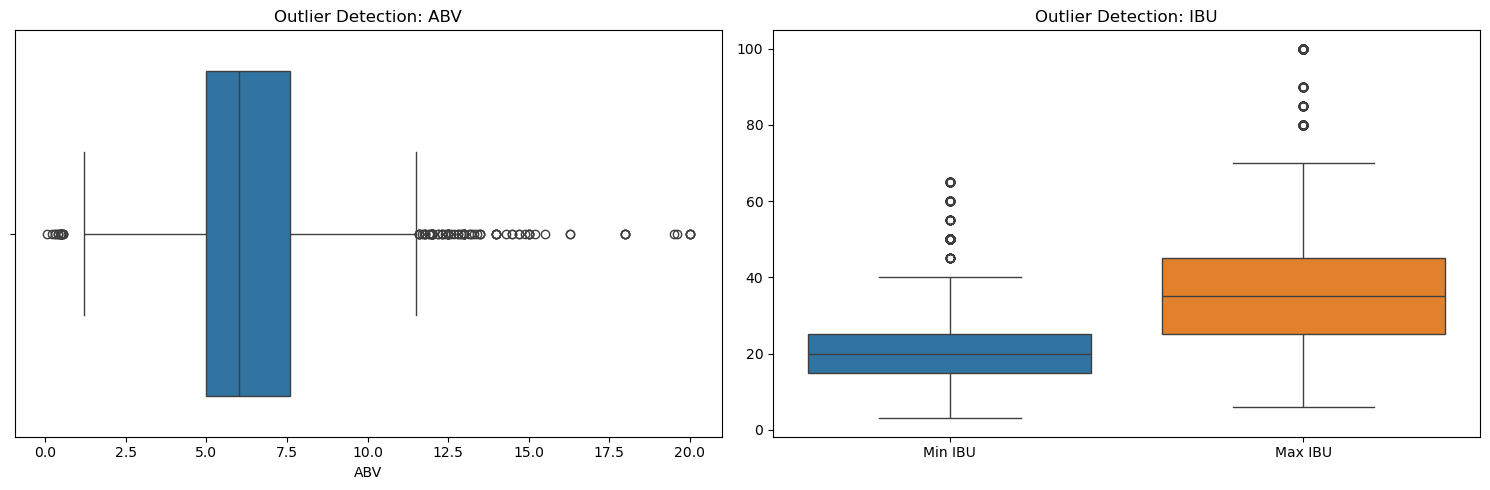

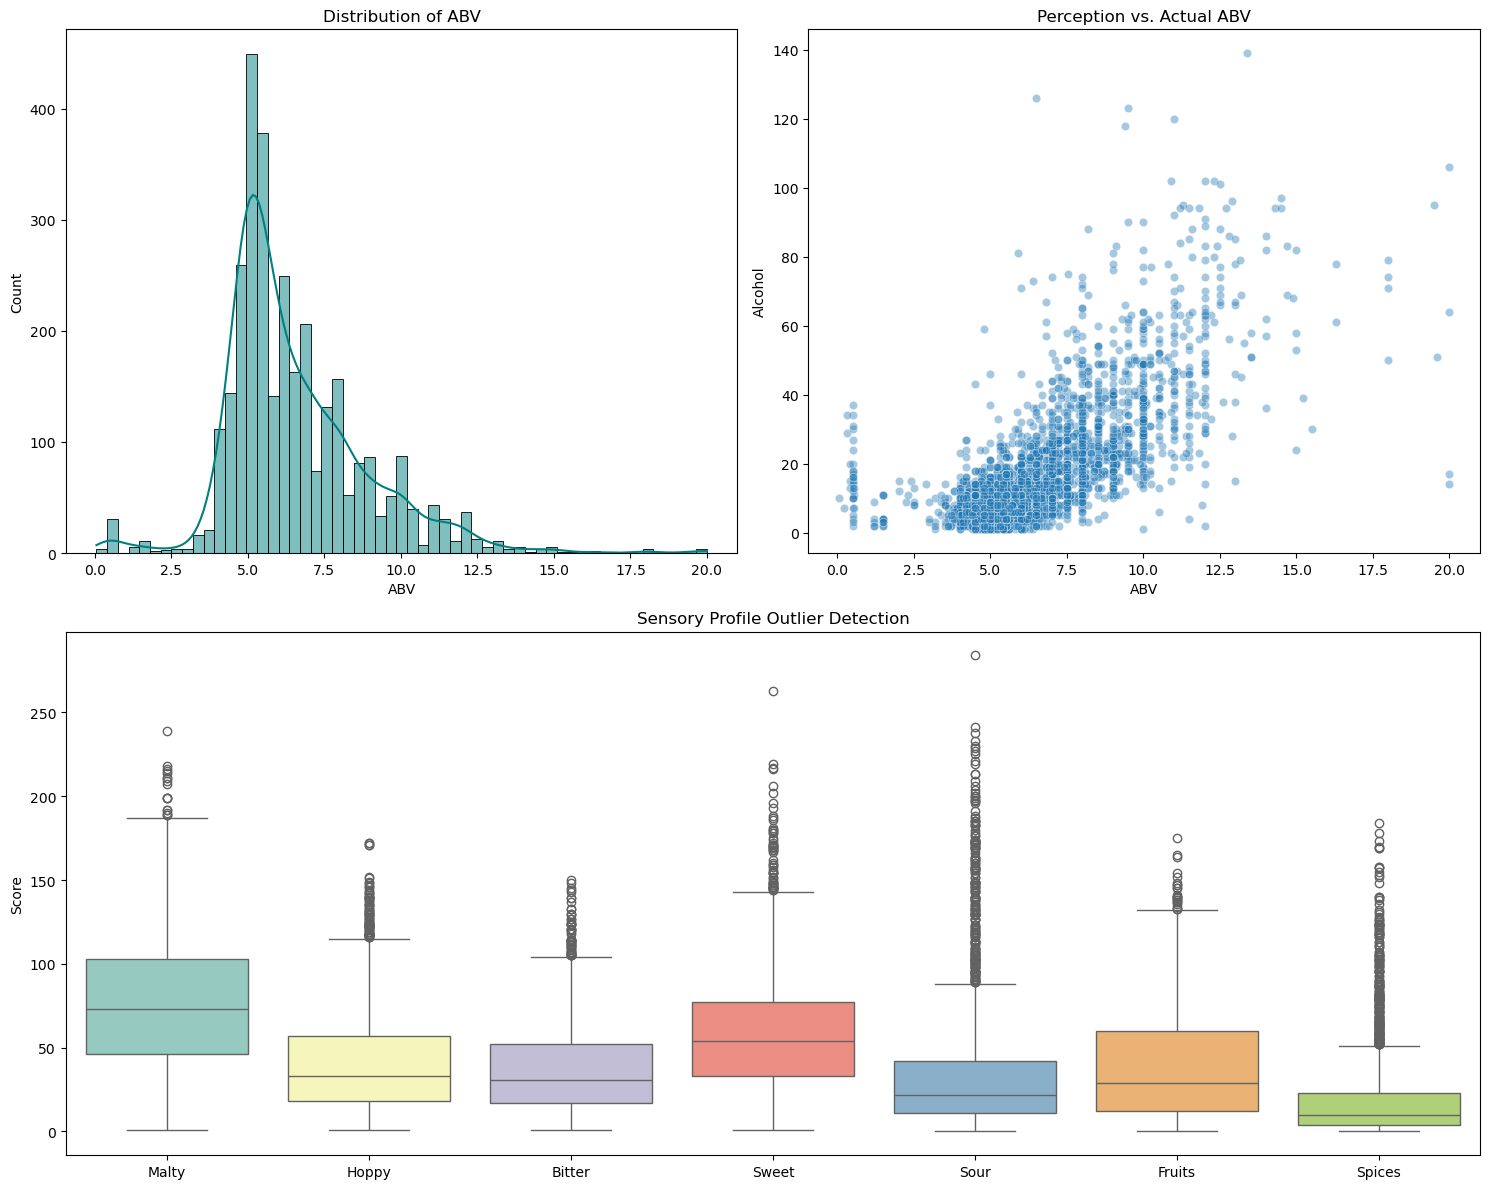

In [13]:
# Outlier detection: ABV and IBU
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=beer_data['ABV'], ax=axes[0])
axes[0].set_title('Outlier Detection: ABV')
sns.boxplot(data=beer_data[['Min IBU', 'Max IBU']], ax=axes[1])
axes[1].set_title('Outlier Detection: IBU')
plt.tight_layout()
plt.show()

# ABV shows most values are clustered fairly close with the median at roughly 5.5. There are some outliers however mainly
# at the 11 mark onward which either indicate an error or just a really strong beer. For IBU there are some outliers that 
# appear as well. For Min IBU, they appear around the 42 mark and for Max IBU they appear around 78. 

# Dashboard: Sensory vs. Technical
fig = plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.histplot(beer_data['ABV'], kde=True, color='teal')
plt.title('Distribution of ABV')

plt.subplot(2, 2, 2)
sns.scatterplot(x='ABV', y='Alcohol', data=beer_data, alpha=0.4)
plt.title('Perception vs. Actual ABV')

plt.subplot(2, 1, 2)
sensory_cols = ['Malty', 'Hoppy', 'Bitter', 'Sweet', 'Sour', 'Fruits', 'Spices']
sensory_cols = [c for c in sensory_cols if c in beer_data.columns]
sns.boxplot(data=beer_data[sensory_cols], palette="Set3")
plt.title('Sensory Profile Outlier Detection')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# The distribution plot shows there is a strong positive skew with the median at roughly 5.5 for ABV. 
# The perception vs. Actual ABV is promising as it shows most reviewers were actually fairly accurate 
# with their ABV sensing. 

## Outlier Handling 

In [16]:
# Capping extreme values at the 99th percentile due to values beyond the 99th percentile are outliers
# that can distort model training. Capping retains these observations while limiting their influence.
outlier_fix_cols = ['Alcohol', 'Body', 'Astringency', 'Malty', 'Sweet',
                    'number_of_reviews']

for col in outlier_fix_cols:
    beer_data[col] = beer_data[col].astype(float)
    upper_limit = beer_data[col].quantile(0.99)
    beer_data.loc[beer_data[col] > upper_limit, col] = upper_limit

# Compares the new Max to the distribution
post_clean_stats = beer_data[outlier_fix_cols].describe(
    percentiles=[.99]).T[['99%', 'max']]
print("Post-Cleaning Statistics:")
print(post_clean_stats)

Post-Cleaning Statistics:
                         99%      max
Alcohol              84.0256    84.16
Body                128.0000   128.00
Astringency          49.0000    49.00
Malty               174.0000   174.00
Sweet               160.0512   160.32
number_of_reviews  1753.4848  1761.28


## Target Transformation

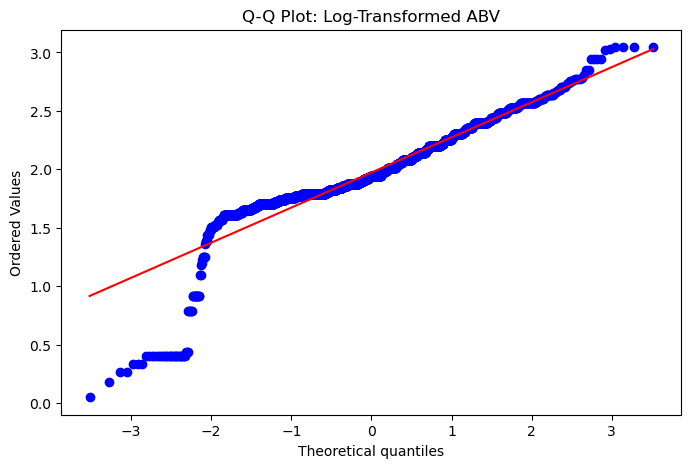

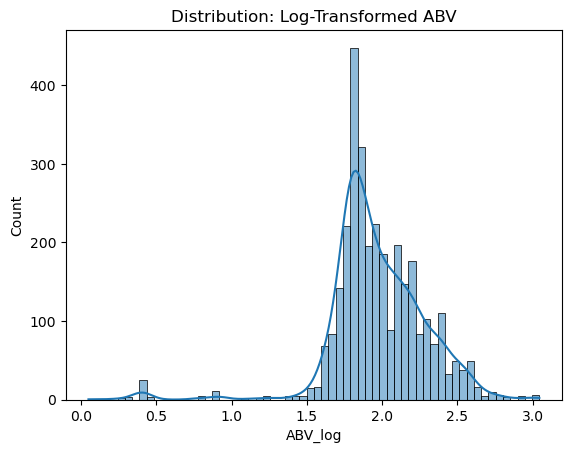

In [19]:
# Log Transformation
beer_data['ABV_log'] = np.log1p(beer_data['ABV'])

plt.figure(figsize=(8, 5))
stats.probplot(beer_data['ABV_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Log-Transformed ABV')
plt.show()

sns.histplot(beer_data['ABV_log'], kde=True)
plt.title('Distribution: Log-Transformed ABV')
plt.show()

# The log transformed ABV did a 180 and made the skew strong negative.


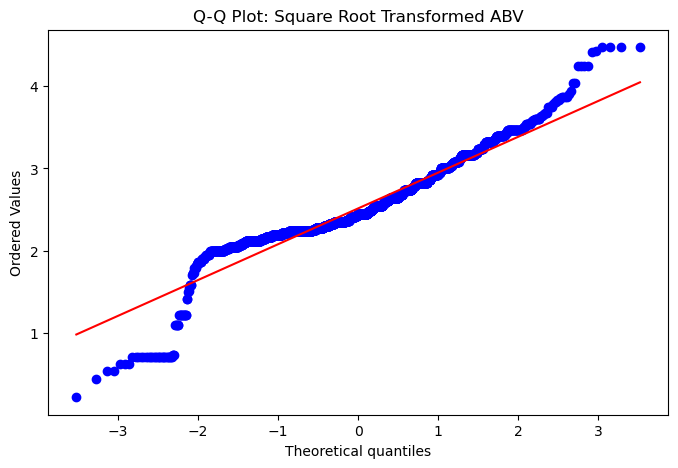

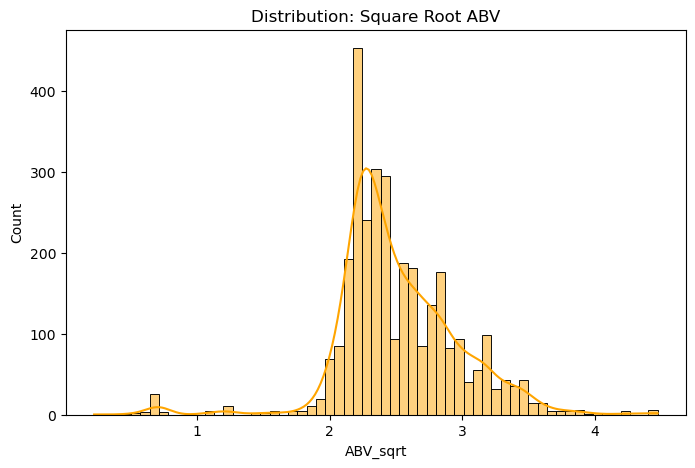

Original ABV Skew: 1.207
Log-Transformed Skew: -1.079
Square Root Skew: -0.034


In [21]:
# Square root transformation
beer_data['ABV_sqrt'] = np.sqrt(beer_data['ABV'])

plt.figure(figsize=(8, 5))
stats.probplot(beer_data['ABV_sqrt'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Square Root Transformed ABV')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(beer_data['ABV_sqrt'], kde=True, color='orange')
plt.title('Distribution: Square Root ABV')
plt.show()

# The Square Root ABV turned out the best at -0.034

# Compare skewness
original_skew = beer_data['ABV'].skew()
log_skew = beer_data['ABV_log'].skew()
sqrt_skew = beer_data['ABV_sqrt'].skew()

print(f"Original ABV Skew: {original_skew:.3f}")
print(f"Log-Transformed Skew: {log_skew:.3f}")
print(f"Square Root Skew: {sqrt_skew:.3f}")

# Square root chosen: skew = -0.034

## Modeling

In [24]:
# Defines features and target.'Alcohol' is excluded to prevent data leakage.
# It directly measures perceived strength and would give the model an unfair
# shortcut to the target.
X = beer_data[['Min IBU', 'Max IBU', 'Body', 'Bitter', 'Hoppy', 'Malty', 'Style']]
y = beer_data['ABV_sqrt']

# Feature categories
num_features = ['Min IBU', 'Max IBU', 'Body', 'Bitter', 'Hoppy', 'Malty']
cat_features = ['Style']

# Preprocessing pipeline. Creates Preprocessing Engine and OneHotEncoder turns Style into numbers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Model pipelines. Creates the Lasso Pipeline for feature selection
lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1))
])

# Creates the Random Forest Pipeline for accuracy
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Splits data 80/20 and trains both models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Cross-Validation

In [26]:
print('--- 5-Fold Cross-Validation Results (sqrt-transformed scale) ---\n')

# Computes 5-fold CV scores for Lasso using negative MAE
lasso_cv_mae = cross_val_score(lasso_pipe, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error')
# Computes 5-fold CV scores for Lasso using negative RMSE 
lasso_cv_rmse = cross_val_score(lasso_pipe, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error')
print(f'Lasso CV MAE (sqrt):  {-lasso_cv_mae.mean():.4f} (+/- {lasso_cv_mae.std():.4f})')
print(f'Lasso CV RMSE (sqrt): {-lasso_cv_rmse.mean():.4f} (+/- {lasso_cv_rmse.std():.4f})')
print()

# Computes 5-fold CV scores for Random Forest using negative MAE
rf_cv_mae = cross_val_score(rf_pipe, X_train, y_train, cv=5,
                             scoring='neg_mean_absolute_error')
# Computes 5-fold CV scores for Random Forest using negative RMSE
rf_cv_rmse = cross_val_score(rf_pipe, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error')
print(f'RF CV MAE (sqrt):  {-rf_cv_mae.mean():.4f} (+/- {rf_cv_mae.std():.4f})')
print(f'RF CV RMSE (sqrt): {-rf_cv_rmse.mean():.4f} (+/- {rf_cv_rmse.std():.4f})')
print()

# 5-fold CV on the sqrt-transformed target shows Random Forest consistently outperforms Lasso
# with RF CV MAE ~0.1699 (0.0060) vs Lasso CV MAE  ~0.2884 (0.0128), and RF CV RMSE ~0.2426 (0.0121) vs Lasso ~0.4041 (0.0232).
# The smaller means and tighter std deviations for RF indicate better and more stable predictive performance across folds.

--- 5-Fold Cross-Validation Results (sqrt-transformed scale) ---

Lasso CV MAE (sqrt):  0.2884 (+/- 0.0128)
Lasso CV RMSE (sqrt): 0.4041 (+/- 0.0232)

RF CV MAE (sqrt):  0.1699 (+/- 0.0060)
RF CV RMSE (sqrt): 0.2426 (+/- 0.0121)



## Model Training and Evaluation

In [28]:
# Train on full training set
lasso_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

def evaluate_model(model, X_test, y_test, name):
    """Evaluates model on both transformed and original ABV scales."""
    preds = model.predict(X_test)

    # Transformed scale metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"--- {name} (sqrt-transformed scale) ---")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")

    # Back-transform to original ABV scale
    preds_original = preds ** 2
    y_test_original = y_test ** 2
    mae_orig = mean_absolute_error(y_test_original, preds_original)
    rmse_orig = np.sqrt(mean_squared_error(y_test_original, preds_original))
    print(f"--- {name} (original ABV % scale) ---")
    print(f"  MAE:  {mae_orig:.4f}% ABV")
    print(f"  RMSE: {rmse_orig:.4f}% ABV")
    print(f"  Typical prediction error: {mae_orig:.2f}% ABV\n")
    return preds

lasso_preds = evaluate_model(lasso_pipe, X_test, y_test, "Lasso Regression")
rf_preds = evaluate_model(rf_pipe, X_test, y_test, "Random Forest")

# Random Forest outperforms Lasso with a typical error ~0.84% ABV for RF vs ~1.40% ABV for Lasso, showing RF captures nonlinearities better.

--- Lasso Regression (sqrt-transformed scale) ---
  MAE:  0.2727
  RMSE: 0.3783
--- Lasso Regression (original ABV % scale) ---
  MAE:  1.3981% ABV
  RMSE: 1.9590% ABV
  Typical prediction error: 1.40% ABV

--- Random Forest (sqrt-transformed scale) ---
  MAE:  0.1602
  RMSE: 0.2245
--- Random Forest (original ABV % scale) ---
  MAE:  0.8359% ABV
  RMSE: 1.2173% ABV
  Typical prediction error: 0.84% ABV



## Actual vs. Predicted Visualization

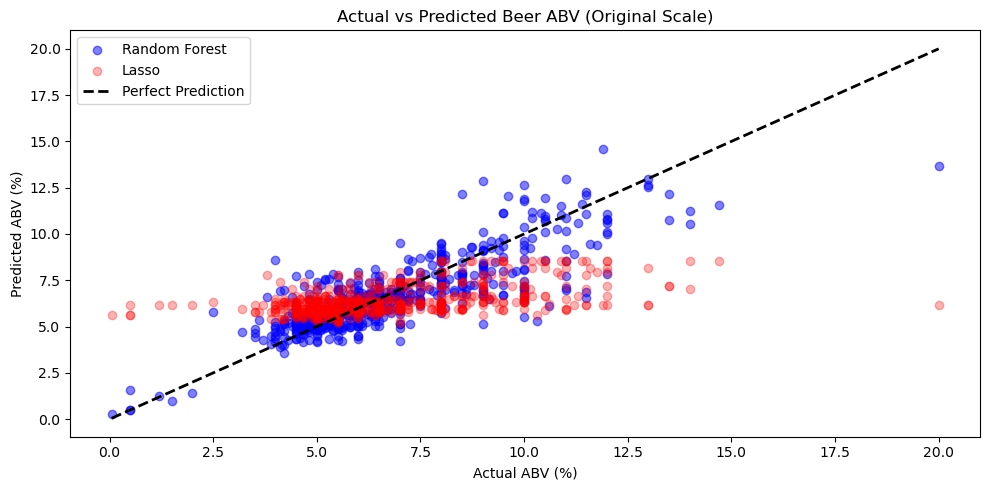

In [30]:
# Back-transform for plotting
rf_preds_orig = rf_preds ** 2
lasso_preds_orig = lasso_preds ** 2
y_test_orig = y_test ** 2

plt.figure(figsize=(10, 5))
plt.scatter(y_test_orig, rf_preds_orig, alpha=0.5, label='Random Forest', color='blue')
plt.scatter(y_test_orig, lasso_preds_orig, alpha=0.3, label='Lasso', color='red')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ABV (%)')
plt.ylabel('Predicted ABV (%)')
plt.title('Actual vs Predicted Beer ABV (Original Scale)')
plt.legend()
plt.tight_layout()
plt.show()

# The plot shows predicted ABV vs actual ABV. Random Forest predictions cluster nearer to the line, 
# while Lasso tends to show a small underestimation at the high end. This shows that the Random Forest 
# appears to perform better overall and that the model is fairly accurate. The prediction error is roughly 0.84% ABV
# for the Random Forest model, and 1.40% ABV for the Lasso Regression model.

## Per Style Error Analysis - Visualization

--- Per-Style Prediction Error (Random Forest, Original ABV Scale) ---
Styles with >= 5 test observations: 71

Top 10 Hardest Styles to Predict:
                   Style  Count  MAE_ABV  Mean_Actual_ABV
                 Braggot      5 2.555182         7.560000
          Bock - Eisbock      5 2.127210        13.980000
   Strong Ale - American      5 2.100348        10.490000
                 Old Ale     11 1.736492         9.581818
  Farmhouse Ale - Saison      7 1.729470         7.442857
    Barleywine - English      5 1.624864        10.928000
         Porter - Baltic      5 1.480131         8.548000
Stout - Russian Imperial      8 1.457539        10.800000
    Strong Ale - English      7 1.445501         6.242857
    Brown Ale - American      9 1.365211         6.094444

Top 10 Easiest Styles to Predict:
                       Style  Count  MAE_ABV  Mean_Actual_ABV
            Lager - American      6 0.315558         4.733333
            Pilsner - German      5 0.269626         4.900

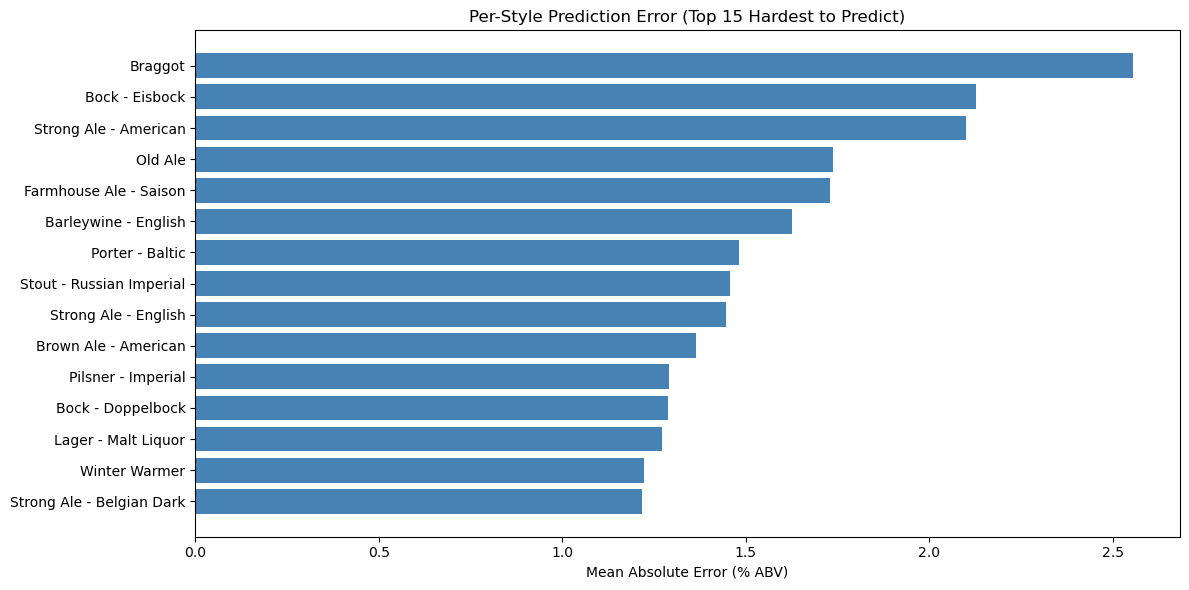

In [24]:
# Per-Style Error Analysis (Random Forest). Examines how prediction accuracy varies across styles,
# identifying where the model is most and least reliable.
results_df = pd.DataFrame({
    'Style': X_test['Style'].values,
    'Actual_ABV': (y_test ** 2).values,
    'Predicted_ABV': rf_preds ** 2,
    'Absolute_Error': abs((y_test ** 2).values - rf_preds ** 2)
})

# Groups results by beer and style
style_errors = results_df.groupby('Style').agg(
    Count=('Absolute_Error', 'count'),
    MAE_ABV=('Absolute_Error', 'mean'),
    Mean_Actual_ABV=('Actual_ABV', 'mean')
).reset_index()

# Filters out styles with fewer than 5 test observations to avoid noisy MAE estimates,
# then sorts styles by MAE descending so the hardest-to-predict styles appear first.
style_errors = style_errors[style_errors['Count'] >= 5].sort_values(
    'MAE_ABV', ascending=False
)

print('--- Per-Style Prediction Error (Random Forest, Original ABV Scale) ---')
print(f'Styles with >= 5 test observations: {len(style_errors)}\n')

# Displays the top 10 hardest styles with the largest MAE (hardest to predict).
print('Top 10 Hardest Styles to Predict:')
print(style_errors.head(10)[['Style', 'Count', 'MAE_ABV', 'Mean_Actual_ABV']]
      .to_string(index=False))
print()

# Displays the top 10 styles with the smallest MAE (easiest to predict).
print('Top 10 Easiest Styles to Predict:')
print(style_errors.tail(10)[['Style', 'Count', 'MAE_ABV', 'Mean_Actual_ABV']]
      .to_string(index=False))

# Visualization - Per-Style Error
fig, ax = plt.subplots(figsize=(12, 6))
top_styles = style_errors.head(15)
ax.barh(top_styles['Style'], top_styles['MAE_ABV'], color='steelblue')
ax.set_xlabel('Mean Absolute Error (% ABV)')
ax.set_title('Per-Style Prediction Error (Top 15 Hardest to Predict)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# The model’s per-style errors show clear differences: 71 styles had >=5 test samples, and many specialty/strong styles
# (e.g., Braggot, Eisbock, American Strong Ale, Barleywine) have high MAE (≈1.4–2.6 ABV points), indicating large absolute mistakes
# for those categories. By contrast, common lagers and light beers (e.g., Lager - European Pale, Pilsner - German, American Lager)
# have low MAE (≈0.11–0.32 ABV points), so the model predicts these reliably. This pattern suggests the model performs well on common,
# narrow-distribution styles but struggles with rarer or high-variance styles—likely due to limited samples, greater within-style ABV variability,
# or missing predictive features for those styles.